# EthStrategy Gamma Scalping + Leveraged Funding Rate

Simulating the bonding mechanics with gamma scalp rebalancing at key levels and funding rate income on leveraged shorts.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import norm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Fetch ETH price data for the last month
end_date = datetime.now()
start_date = end_date - timedelta(days=30)

eth_data = yf.download('ETH-USD', start=start_date, end=end_date, interval='1h', progress=False)
eth_data = eth_data.dropna()

# Flatten MultiIndex columns
if isinstance(eth_data.columns, pd.MultiIndex):
    eth_data.columns = ['_'.join(col).strip() for col in eth_data.columns.values]

# Rename to simple names
eth_data = eth_data.rename(columns={
    'Close_ETH-USD': 'Close',
    'High_ETH-USD': 'High',
    'Low_ETH-USD': 'Low',
    'Open_ETH-USD': 'Open',
    'Volume_ETH-USD': 'Volume'
})

print(f"ETH Data from {start_date.date()} to {end_date.date()}")
print(f"Period: {len(eth_data)} hours")
close_min = float(eth_data['Close'].min())
close_max = float(eth_data['Close'].max())
print(f"Price range: ${close_min:.2f} - ${close_max:.2f}")
print(f"\nFirst few rows:")
print(eth_data[['Close', 'High', 'Low', 'Open']].head())

ETH Data from 2026-03-06 to 2026-04-05
Period: 711 hours
Price range: $1931.13 - $2360.50

First few rows:
                                 Close         High          Low         Open
Datetime                                                                     
2026-03-06 12:00:00+00:00  2051.464600  2054.358887  2038.809082  2051.493164
2026-03-06 13:00:00+00:00  2024.777954  2056.569824  2022.625000  2048.889404
2026-03-06 14:00:00+00:00  1975.829102  2021.852295  1975.829102  2020.914307
2026-03-06 15:00:00+00:00  1977.029175  1995.913574  1968.190796  1982.579468
2026-03-06 16:00:00+00:00  1972.444092  1984.421631  1967.782471  1978.013916


In [11]:
# Black-Scholes option pricing and Greeks
def bs_price_and_greeks(S, K, T, r, sigma, option_type='call'):
    """
    Calculate option price and greeks using Black-Scholes
    S: spot price
    K: strike price
    T: time to expiry (years)
    r: risk-free rate
    sigma: volatility (annualized)
    """
    if T <= 0:
        return {'price': 0, 'delta': 0, 'gamma': 0, 'vega': 0, 'theta': 0}
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        vega = S * norm.pdf(d1) * np.sqrt(T) / 100
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - 
                 r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    
    return {
        'price': float(price),
        'delta': float(delta),
        'gamma': float(gamma),
        'vega': float(vega),
        'theta': float(theta)
    }

print("Black-Scholes Greeks calculator loaded")

Black-Scholes Greeks calculator loaded


In [12]:
# Strategy parameters
BOND_AMOUNT = 100_000  # USD bonded
CDT_TOTAL = 100_000    # Total CDT tokens
CDT_VALUE = 0.50       # CDT price = $0.50
CDT_USD = CDT_TOTAL * CDT_VALUE  # = $50k

# Option parameters
INITIAL_SPOT = float(eth_data['Close'].iloc[0])  # Start from first day's price
OTM_STRIKE_PCT = 0.15  # 15% OTM initial call
INITIAL_STRIKE = INITIAL_SPOT * (1 + OTM_STRIKE_PCT)
OPTION_TENOR = 4.0  # 4 years
r = 0.05  # risk-free rate

# Leverage parameters
LEVERAGE = 3.0  # 3x leverage on shorts
AVG_FUNDING_RATE = 0.00005  # 5 bps per day (typical bull market)

# Rebalancing parameters
REBALANCE_THRESHOLD = 0.05  # Rebalance at 5% moves from entry

print(f"Strategy Parameters:")
print(f"  Bonded: ${BOND_AMOUNT:,.0f}")
print(f"  CDT Tokens: {CDT_TOTAL:,.0f} @ ${CDT_VALUE} = ${CDT_USD:,.0f}")
print(f"  Initial Spot: ${INITIAL_SPOT:.2f}")
print(f"  Initial Strike (15% OTM): ${INITIAL_STRIKE:.2f}")
print(f"  Leverage on Shorts: {LEVERAGE}x")
print(f"  Daily Funding Rate: {AVG_FUNDING_RATE*100:.3f}%")

Strategy Parameters:
  Bonded: $100,000
  CDT Tokens: 100,000 @ $0.5 = $50,000
  Initial Spot: $2051.46
  Initial Strike (15% OTM): $2359.18
  Leverage on Shorts: 3.0x
  Daily Funding Rate: 0.005%


In [13]:
# Calculate historical volatility from the price data
returns = eth_data['Close'].pct_change().dropna()
hist_vol = returns.std() * np.sqrt(365 * 24)  # Annualized hourly returns
print(f"Historical volatility (annualized): {hist_vol:.2%}")

Historical volatility (annualized): 58.54%


In [14]:
# Simulate the strategy
results = []
rebonds = []  # Track rebonding events

# Track positions
call_positions = []  # List of {entry_price, strike, notional, entry_date, price, delta, gamma, theta}
short_eth = 0  # ETH amount shorted with leverage
short_price = INITIAL_SPOT
cdt_remaining = CDT_USD  # Remaining CDT value in USD

# Initial position
call_positions.append({
    'entry_price': INITIAL_SPOT,
    'strike': INITIAL_STRIKE,
    'notional': BOND_AMOUNT,
    'entry_date': eth_data.index[0],
    'rebonded': False,
    'price': 0,
    'delta': 0,
    'gamma': 0,
    'theta': 0
})

for i, (idx, row) in enumerate(eth_data.iterrows()):
    spot = float(row['Close'])
    days_elapsed = (idx - eth_data.index[0]).days + (idx - eth_data.index[0]).seconds / (24 * 3600)
    years_elapsed = days_elapsed / 365
    
    # Calculate Greeks for each call position
    total_delta = 0
    total_gamma = 0
    total_call_value = 0
    active_calls = 0
    
    for call in call_positions:
        T_remaining = OPTION_TENOR - years_elapsed
        if T_remaining <= 0:
            continue
        
        active_calls += 1
        greeks = bs_price_and_greeks(spot, call['strike'], T_remaining, r, hist_vol, 'call')
        call['price'] = greeks['price']
        call['delta'] = greeks['delta']
        call['gamma'] = greeks['gamma']
        call['theta'] = greeks['theta']
        
        call_notional = call['notional']  # In dollars
        call_qty = call_notional / spot  # ETH equivalent
        
        total_delta += call['delta'] * call_qty
        total_gamma += call['gamma'] * call_qty
        total_call_value += greeks['price'] * call_qty
    
    # Current delta of portfolio (call is long)
    current_delta = total_delta
    
    # Rebalance shorts if delta drifts
    target_short = current_delta * LEVERAGE  # 3x leverage on delta
    
    if abs(target_short - short_eth) > 0.1 or i == 0:
        short_eth = target_short
        short_price = spot
    
    hedge_notional = short_eth * spot
    
    # Funding rate P&L
    funding_pnl = hedge_notional * AVG_FUNDING_RATE
    
    # Short position P&L (unrealized)
    if i > 0:
        prev_spot = float(eth_data['Close'].iloc[i-1])
        short_pnl = short_eth * (short_price - spot)
    else:
        short_pnl = 0
    
    # Net portfolio delta
    net_delta = current_delta - short_eth
    
    # Check for rebalancing at key levels
    should_rebond = False
    if len(call_positions) > 0 and cdt_remaining > 0:
        last_call = call_positions[-1]
        price_move = abs(spot - last_call['entry_price']) / last_call['entry_price']
        
        if price_move > REBALANCE_THRESHOLD and not last_call['rebonded']:
            # Rebond: take the CDT, get a new ATM call
            should_rebond = True
            last_call['rebonded'] = True
            
            # New ATM call at current spot
            new_notional = cdt_remaining  # Use remaining CDT value
            call_positions.append({
                'entry_price': spot,
                'strike': spot,  # ATM
                'notional': new_notional,
                'entry_date': idx,
                'rebonded': False,
                'price': 0,
                'delta': 0,
                'gamma': 0,
                'theta': 0
            })
            
            rebonds.append({
                'date': idx,
                'spot': spot,
                'strike': spot,
                'notional': new_notional
            })
            
            cdt_remaining = 0  # CDT consumed
    
    results.append({
        'date': idx,
        'spot': spot,
        'delta': current_delta,
        'gamma': total_gamma,
        'call_value': total_call_value,
        'short_eth': short_eth,
        'short_pnl': short_pnl,
        'funding_pnl': funding_pnl,
        'total_pnl': short_pnl + funding_pnl,
        'net_delta': net_delta,
        'num_calls': active_calls,
        'rebonded': should_rebond
    })

df_results = pd.DataFrame(results)
print(f"\nBacktest complete. Simulated {len(df_results)} hours of trading.")
print(f"Rebonding events: {len(rebonds)}")


Backtest complete. Simulated 711 hours of trading.
Rebonding events: 1


In [15]:
# Summary statistics
print("\n=== BACKTEST SUMMARY ===")
print(f"\nPrice Movement:")
print(f"  Start: ${df_results['spot'].iloc[0]:.2f}")
print(f"  End: ${df_results['spot'].iloc[-1]:.2f}")
print(f"  Min: ${df_results['spot'].min():.2f}")
print(f"  Max: ${df_results['spot'].max():.2f}")
print(f"  Total Change: {(df_results['spot'].iloc[-1] / df_results['spot'].iloc[0] - 1)*100:.2f}%")

print(f"\nP&L Analysis:")
df_results['cumulative_pnl'] = df_results['total_pnl'].cumsum()
print(f"  Total Funding Rate P&L: ${df_results['funding_pnl'].sum():,.2f}")
print(f"  Total Short Hedge P&L: ${df_results['short_pnl'].sum():,.2f}")
print(f"  Combined P&L: ${df_results['total_pnl'].sum():,.2f}")
print(f"  Max Drawdown: ${df_results['cumulative_pnl'].min():,.2f}")
print(f"  Max Gain: ${df_results['cumulative_pnl'].max():,.2f}")

print(f"\nDelta Management:")
print(f"  Avg Net Delta: {df_results['net_delta'].mean():.4f}")
print(f"  Max Net Delta: {df_results['net_delta'].max():.4f}")
print(f"  Min Net Delta: {df_results['net_delta'].min():.4f}")

if len(rebonds) > 0:
    print(f"\nRebonding Events:")
    for rebond in rebonds:
        print(f"  {rebond['date'].date()}: Spot ${rebond['spot']:.2f} → New ATM call ${rebond['notional']:,.0f}")


=== BACKTEST SUMMARY ===

Price Movement:
  Start: $2051.46
  End: $2057.97
  Min: $1931.13
  Max: $2360.50
  Total Change: 0.32%

P&L Analysis:
  Total Funding Rate P&L: $11,905.47
  Total Short Hedge P&L: $2,577.62
  Combined P&L: $14,483.09
  Max Drawdown: $-88.62
  Max Gain: $14,575.60

Delta Management:
  Avg Net Delta: -106.7394
  Max Net Delta: -71.9364
  Min Net Delta: -114.6869

Rebonding Events:
  2026-03-08: Spot $1941.61 → New ATM call $50,000


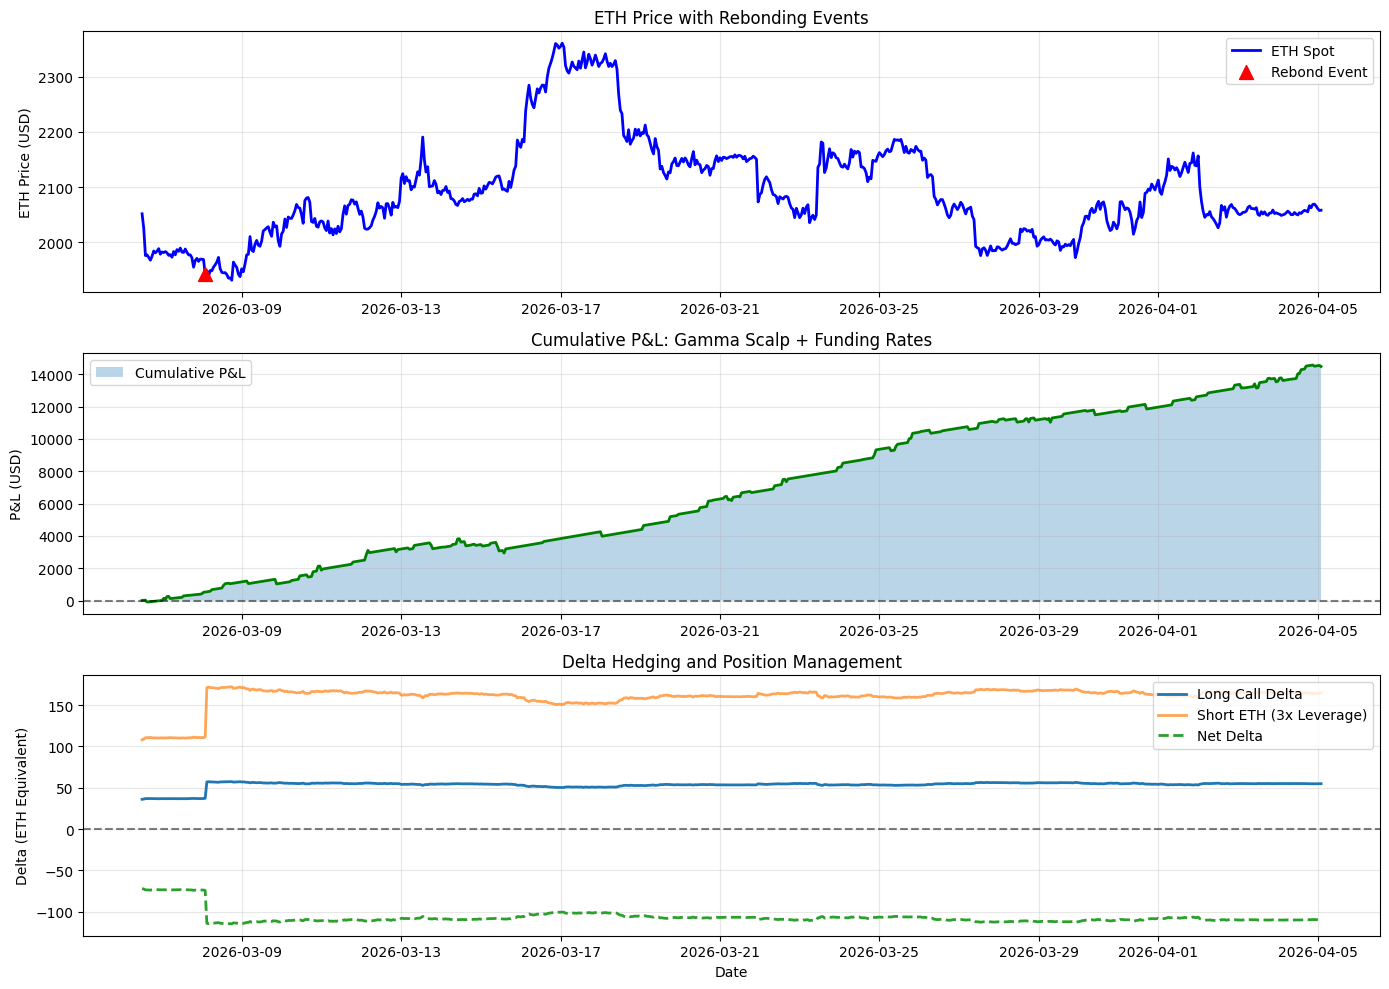

In [16]:
# Visualizations
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Spot price and rebonding events
axes[0].plot(df_results['date'], df_results['spot'], label='ETH Spot', linewidth=2, color='blue')
if len(rebonds) > 0:
    rebond_dates = [r['date'] for r in rebonds]
    rebond_spots = [r['spot'] for r in rebonds]
    axes[0].scatter(rebond_dates, rebond_spots, color='red', s=100, marker='^', label='Rebond Event', zorder=5)
axes[0].set_ylabel('ETH Price (USD)')
axes[0].set_title('ETH Price with Rebonding Events')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cumulative P&L
axes[1].fill_between(df_results['date'], 0, df_results['cumulative_pnl'], alpha=0.3, label='Cumulative P&L')
axes[1].plot(df_results['date'], df_results['cumulative_pnl'], linewidth=2, color='green')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_ylabel('P&L (USD)')
axes[1].set_title('Cumulative P&L: Gamma Scalp + Funding Rates')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Delta and Leverage
axes[2].plot(df_results['date'], df_results['delta'], label='Long Call Delta', linewidth=2)
axes[2].plot(df_results['date'], df_results['short_eth'], label='Short ETH (3x Leverage)', linewidth=2, alpha=0.7)
axes[2].plot(df_results['date'], df_results['net_delta'], label='Net Delta', linewidth=2, linestyle='--')
axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Delta (ETH Equivalent)')
axes[2].set_title('Delta Hedging and Position Management')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Detailed P&L breakdown
print("\n=== DETAILED P&L BREAKDOWN ===")
print(f"\nFunding Rate Income (Daily):")
print(f"  Average Daily: ${df_results['funding_pnl'].mean():.2f}")
print(f"  Total Period: ${df_results['funding_pnl'].sum():.2f}")
avg_notional = (df_results['short_eth'] * df_results['spot']).mean()
annualized_funding = (df_results['funding_pnl'].sum() / BOND_AMOUNT) * (365/30)
print(f"  Annualized on Bond: {annualized_funding:.2%}")

print(f"\nGamma Scalping P&L (Rehedging):")
print(f"  Total Realized: ${df_results['short_pnl'].sum():,.2f}")
if len(rebonds) > 0:
    print(f"  Rebonding events: {len(rebonds)}")

print(f"\nRisk Metrics:")
print(f"  Max Intra-period Loss: ${df_results['cumulative_pnl'].min():,.2f}")
if df_results['total_pnl'].std() > 0:
    sharpe = (df_results['total_pnl'].mean() / df_results['total_pnl'].std()) * np.sqrt(365*24)
    print(f"  Sharpe Ratio: {sharpe:.2f}")


=== DETAILED P&L BREAKDOWN ===

Funding Rate Income (Daily):
  Average Daily: $16.74
  Total Period: $11905.47
  Annualized on Bond: 144.85%

Gamma Scalping P&L (Rehedging):
  Total Realized: $2,577.62
  Rebonding events: 1

Risk Metrics:
  Max Intra-period Loss: $-88.62
  Sharpe Ratio: 24.97


In [18]:
# Export results for further analysis
df_results.to_csv('/Users/miffy/strat/meteora_LP/eth_strategy_backtest.csv', index=False)
print("Results exported to eth_strategy_backtest.csv")

Results exported to eth_strategy_backtest.csv
